<a href="https://colab.research.google.com/github/Dramy8/DI_Bootcamp/blob/main/Week04/Day5/Ex_XP/xpgold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

Exercise 1: Data Scaling and Normalization
Instructions
Identify numerical columns in the dataset like ‘Fare’ and ‘Age’.
Apply standardization (Z-score scaling) to features with a Gaussian distribution.
Apply Min-Max normalization to features that require bounded ranges.
Analyze the effect of scaling and normalization on model performance.
Hint: Use StandardScaler and MinMaxScaler from scikit-learn.



In [3]:
df=pd.read_csv('train.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print(num_cols)

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [10]:
standard_scaler = StandardScaler()
df[['Age', 'Fare']] = standard_scaler.fit_transform(df[['Age', 'Fare']])

In [11]:
df_minmax = df.copy()
min_max_scaler = MinMaxScaler()
df_minmax[['Age', 'Fare']] = min_max_scaler.fit_transform(df_minmax[['Age', 'Fare']])

In [13]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,7.140000e+02,891.000000,891.000000,8.910000e+02
mean,446.000000,0.383838,2.308642,2.388379e-16,0.523008,0.381594,3.987333e-18
std,257.353842,0.486592,0.836071,1.000701e+00,1.102743,0.806057,1.000562e+00
min,1.000000,0.000000,1.000000,-2.016979e+00,0.000000,0.000000,-6.484217e-01
25%,223.500000,0.000000,2.000000,-6.595416e-01,0.000000,0.000000,-4.891482e-01
50%,446.000000,0.000000,3.000000,-1.170488e-01,0.000000,0.000000,-3.573909e-01
75%,668.500000,1.000000,3.000000,5.718310e-01,1.000000,0.000000,-2.424635e-02
max,891.000000,1.000000,3.000000,3.465126e+00,8.000000,6.000000,9.667167e+00


In [14]:
df_minmax.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.367921,0.523008,0.381594,0.062858
std,257.353842,0.486592,0.836071,0.182540,1.102743,0.806057,0.096995
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.247612,0.000000,0.000000,0.015440
50%,446.000000,0.000000,3.000000,0.346569,0.000000,0.000000,0.028213
75%,668.500000,1.000000,3.000000,0.472229,1.000000,0.000000,0.060508
max,891.000000,1.000000,3.000000,1.000000,8.000000,6.000000,1.000000


Scaling changes the numerical range of the features without changing their relative order. Standardization centers the data around zero and scales it based on standard deviation, while Min-Max normalization rescales values between 0 and 1. These transformations can improve the performance of models that are sensitive to feature scale, such as KNN, SVM, K-Means, and PCA. However, no model was trained here; the comparison focuses on how the values and ranges change.

Exercise 2: Creating Composite Features
Instructions
Create a new feature, ‘Family Size’, by combining ‘SibSp’ (siblings and spouses) and ‘Parch’ (parents and children).
Create a ‘IsAlone’ feature to indicate whether a passenger is traveling alone.
Explore the relationship between these new features and the survival rate.
Hint: Use basic arithmetic operations and conditional statements in Pandas.



In [28]:
import numpy as np
df_features = df.copy()
df_features['Family Size'] = df_features['SibSp'] + df_features['Parch'] + 1
df_features['IsAlone'] = np.where(df_features['Family Size'] == 1, 1, 0)

In [29]:
df_features.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,-0.530377,1,0,A/5 21171,-0.502445,NaN,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.571831,1,0,PC 17599,0.786845,C85,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,-0.254825,0,0,STON/O2. 3101282,-0.488854,NaN,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.365167,1,0,113803,0.420730,C123,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,0.365167,0,0,373450,-0.486337,NaN,S,1,1


In [30]:
survival_alone = df_features.groupby('IsAlone')['Survived'].mean()
survival_alone

,Survived
IsAlone,
0,0.505650
1,0.303538


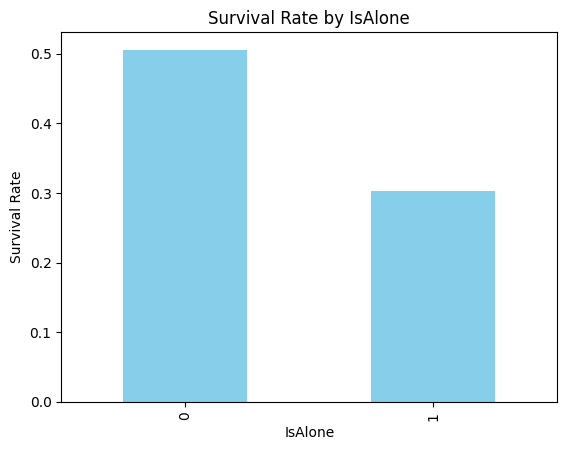

In [31]:
survival_alone.plot.bar(x='IsAlone', y='Survived', color='skyblue')

plt.title("Survival Rate by IsAlone")
plt.xlabel("IsAlone")
plt.ylabel("Survival Rate")
plt.show()


In [32]:
family_survival_rate = df_features.groupby('Family Size')['Survived'].mean()
family_survival_rate

,Survived
Family Size,
1,0.303538
2,0.552795
3,0.578431
4,0.724138
5,0.200000
6,0.136364
7,0.333333
8,0.000000
11,0.000000


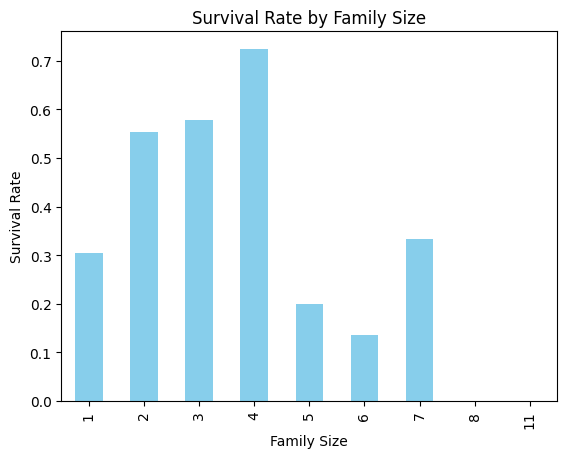

In [33]:
family_survival_rate.plot.bar(x='Family Size', y='Survived', color='skyblue')

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.show()

Exercise 4 : Data Reduction and Aggregation
Instructions
Perform data reduction on the titanic dataset by implementing dimensionality reduction techniques like Principal Component Analysis (PCA).
Aggregate the data by a categorical column (like date or region) and calculate summary statistics (mean, sum, etc.).
Visualize the aggregated data using appropriate plots.


In [35]:
from sklearn.decomposition import PCA

pca_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Family Size']

X_pca = df_features[pca_cols].copy()


In [36]:
X_pca.isnull().sum()

,0
Age,177
Fare,0
SibSp,0
Parch,0
Family Size,0


In [37]:
X_pca['Age'] = X_pca['Age'].fillna(X_pca['Age'].median())

In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

In [39]:
pca = PCA(n_components=2)

X_pca_result = pca.fit_transform(X_scaled)

In [40]:
df_pca = pd.DataFrame(
    X_pca_result,
    columns=['PC1', 'PC2']
)

df_pca.head()

,PC1,PC2
0,0.056726,-0.821527
1,0.039095,0.948511
2,-0.874336,-0.539473
3,0.018126,0.526781
4,-1.025306,-0.065917


In [43]:
pca.explained_variance_ratio_.sum()

np.float64(0.7340051195214952)